# Setup

In [1]:
# import libraries used in this notebook
from scipy.io import loadmat
import pandas as pd
import numpy as np
import glob
import os
import re
import google.colab.drive as drive
from scipy.stats import norm
import math
import scipy.integrate as integrate
from typing import List
import matplotlib.pyplot as plt

In [2]:
# mount your google drive to this colab runtime
mountpoint = '/content/G' # arbitrary mountpoint
drive.mount(mountpoint)
# when prompted, connect to account with access to LC project

Mounted at /content/G


In [3]:
%xmode Verbose

Exception reporting mode: Verbose


In [4]:
# @title Helper Functions

def create_sub_list(data_dir, search_pat='/*MST*.mat'):
    # List of directories with search_pat
    folders = glob.glob(data_dir + search_pat)

    # Extract subject IDs from directories with data
    sub_list = []
    for path in folders:  # Use filtered list of directories with data
      basename = os.path.basename(path)
      sub_list.append(basename.split("_")[0].replace("subject", ""))
    return sub_list

def check_missing_data_lcya(data_dir, search_pat='/*MST*'):
    # Get all data file paths that match the search pattern
    all_data_paths = glob.glob(data_dir + search_pat)

    # Get the list of names of behavioral files
    beh_data_names = sorted([
        os.path.splitext(os.path.basename(path))[0] for path in all_data_paths
        if '.mat' in path and 'MVCnPRAC' not in path and 'eyetrack' not in path
    ])
    print(f"Num beh files: {len(beh_data_names)}")
    # Get the list of names of gripforce data
    grip_data_names = sorted([
        os.path.splitext(os.path.basename(path))[0].replace('_gripforce', '', 1) for path in all_data_paths
        if '_gripforce' in path and 'MVCnPRAC' not in path
    ])
    print(f"Num grip files: {len(grip_data_names)}")

    # Check that each behavioral file has a corresponding grip and eyetracking data
    # Find non-matching elements between behavioral and gripforce data
    beh_vs_grip_diff = set(beh_data_names) ^ set(grip_data_names)

    # Print any non-matching elements found
    print(f"\n{len(beh_vs_grip_diff)} Non-matching behavioral and gripforce data:")
    [print(f'{file}') for file in sorted(beh_vs_grip_diff)]

def integrate_grip(gripforce_col):
  # integration function for gripforce in csv (to compute AUC)
  auc = integrate.trapz(gripforce_col)/len(gripforce_col)
  return auc

def create_grip_measures_lcya(run_data, grip_filepath, create_gripplots):
  # if gripforce file exists:
  if os.path.isfile(grip_filepath):

    # set parameters for valid_grip
    time_window_lower_bound = 1 # seconds
    time_window_upper_bound = 3 # seconds
    hi_grip_lower = 0.30
    hi_grip_upper = 0.55
    lo_grip_lower = 0.01
    lo_grip_upper = 0.15

    # read data from grip files corresponding to MAT file (_gripforce.csv)
    csv_data_run = pd.read_csv(grip_filepath)
    csv_data_run.columns = ['gripforce', 'time_since_func_call', 'trial', 'func_call_time_ptb', 'time_ptb', 'time_since_trial_start']

    # do a few to many merge with run_data (beh) to get isStrengthHi and mvc columns
    csv_data_merged = csv_data_run.merge(run_data[['trial', 'isStrengthHi', 'mvc']], on='trial', how='right')

    # subset for samples within our range
    csv_data_merged_valid_time = csv_data_merged.query(f"(time_since_trial_start>={time_window_lower_bound}) & (time_since_trial_start<={time_window_upper_bound})").reset_index(drop=True)

    # create proportion mvc column
    csv_data_merged_valid_time['proportion_mvc'] = csv_data_merged_valid_time.gripforce/csv_data_merged_valid_time.mvc

    # set tagging conditions for valid samples and add to gripforce data
    valid_grip_range_cond = [
      # hi, valid
      (csv_data_merged_valid_time.proportion_mvc >= hi_grip_lower) & (csv_data_merged_valid_time.proportion_mvc < hi_grip_upper) & (csv_data_merged_valid_time.isStrengthHi==1),
      # lo valid
      (csv_data_merged_valid_time.proportion_mvc >= lo_grip_lower) & (csv_data_merged_valid_time.proportion_mvc < lo_grip_upper) & (csv_data_merged_valid_time.isStrengthHi==0),
      # hi, invalid
      ((csv_data_merged_valid_time.proportion_mvc < hi_grip_lower) | (csv_data_merged_valid_time.proportion_mvc >= hi_grip_upper)) & (csv_data_merged_valid_time.isStrengthHi==1),
      # lo, invalid
      ((csv_data_merged_valid_time.proportion_mvc < lo_grip_lower) | (csv_data_merged_valid_time.proportion_mvc >= lo_grip_upper)) & (csv_data_merged_valid_time.isStrengthHi==0),
    ]
    valid_grip_range_val = [1, 1, 0, 0]
    csv_data_merged_valid_time['valid_grip_sample'] = np.select(valid_grip_range_cond, valid_grip_range_val)

    # add a column in run_data for proportion of valid grip samples
    run_data['prop_valid_grip_samples'] = csv_data_merged_valid_time.groupby("trial").mean(numeric_only=True).reset_index()['valid_grip_sample']

    # add a column to get the area uner the curve of gripforce trajectories
    run_data['auc'] = csv_data_run.groupby("trial").agg({"gripforce":integrate_grip}).values

    if create_gripplots:
      trials = csv_data_run.trial.unique()
      # create a spaghetti plot of gripforce over time per trial
      for trial in trials:
        trial_grip_data = csv_data_run.query(f'trial=={trial}').reset_index()
        # zero-out the time for each trial by subtracting time array with its first index
        x = trial_grip_data.time_since_trial_start
        # express the gripforce in proportion MVC
        y = trial_grip_data.gripforce/trial_grip_data.mvc
        plt.scatter(x, y, s=0.3, marker='.')
        plt.ylim(0, 1)
      # save plot
      plot_filepath = grip_filepath.replace('csv', 'png')
      plt.savefig(plot_filepath)

  else:
    print(f'Gripforce file does not exists: \n{os.path.basename(grip_filepath)}\n---------')
    run_data['auc'] = np.nan
    run_data['prop_valid_grip_samples'] = np.nan
  return run_data

def agg_trial_level_data_lcya(sub_list: List[str], mat_vars: List[str], data_dir, search_pat, get_grip_measures=True) -> pd.DataFrame:
  try:
    # set up and display function progress info
    n_subj = len(sub_list)
    n_subj_finished = 0
    print(f"Aggregating {n_subj}")

    # initialize final dataframe
    all_data = pd.DataFrame(columns=mat_vars)

    # loop through all subject IDs in sub_list
    for sub in sub_list:
      # get all scanner files
      sub_pat = data_dir+f'/subject{sub}_'+search_pat # THIS IS DIFFERENT COMPARED TO BAP
      sub_files = glob.glob(sub_pat)
      # filter for task/behavioral files only
      sub_files_beh = sorted([file for file in sub_files
                      if '.mat' in file
                      and 'MVCnPRAC' not in file
                              ])

      sub_files_grip = sorted([file for file in sub_files
                      if '.csv' in file
                      and 'MVCnPRAC' not in file
                            ])
      num_files_beh = len(sub_files_beh)
      num_files_grip = len(sub_files_grip)

      if num_files_beh != num_files_grip:
        print(f"WARNING: number of MAT {num_files_beh} and CSV {num_files_grip} files are NOT equal for subject {sub}! \nMake sure your subject/search pattern is corect: {sub_pat}.")

      for file_i in range(0, num_files_beh):
        # read data from behavioral file (.mat)
        mat_data = loadmat(sub_files_beh[file_i])
        # initialize temporary empty dataframe for each run
        run_data = pd.DataFrame()
        for var in mat_vars:
          if var=='MSTstudy':
            trials = np.arange(0, len(mat_data['mixtr']))
            RImsets = mat_data['RImsets']
            mixtr = mat_data['mixtr'] # this is the MST study-specific mixtr
            im_num = []
            for trial in trials:
              im_num.append(RImsets[mixtr[trial, 0]-1, mixtr[trial, 1]-1])
            run_data['im_num'] = im_num
            run_data['trial_type'] = mixtr[:, 0]
          elif var=='MSTtest':
            trials = np.arange(0, len(mat_data['mixtr2']))
            RImsets = mat_data['RImsets']
            mixtr = mat_data['mixtr2'] # this is the MST test-specific mixtr
            im_num = []
            for trial in trials:
              im_num.append(RImsets[mixtr[trial, 0]-1, mixtr[trial, 1]-1])
            run_data['im_num'] = im_num
            run_data['trial_type'] = mixtr[:, 0]
          elif len(mat_data[var][0])==1:
            # vars with >1 length need to be indexed twice
            # to be properly accessed
            run_data[var] = mat_data[var][0][0]
          else:
            # regular array variables
            run_data[var] = mat_data[var][0]

          # add a trial index and filepath variable
          run_data['trial'] = run_data.index+1
          run_data['filepath'] = sub_files_beh[file_i]

        if get_grip_measures:
          grip_filepath = sub_files_beh[file_i].replace('.mat', '_gripforce.csv')
          # call create_grip_measures
          run_data = create_grip_measures_lcya(run_data, grip_filepath=grip_filepath, create_gripplots=False)

        # concatentate to final dataframe
        all_data = pd.concat([all_data, run_data])

        # end of file/run loop
      n_subj_finished = n_subj_finished+1
      print(f"sub-{sub}: ({n_subj_finished}/{n_subj})")
      # end of subject loop

    if get_grip_measures:
      # calculate additional gripforce auc-related measures:
      # auc_prop_targ is a participant's gripforce AUC relative to a "perfect" AUC for that trial (e.g 3 seconds squeeze at 40% mvc)
      all_data['auc_prop_targ'] = all_data['auc']/(all_data['gf_trPer']*all_data['mvc'])
      # auc_rel_mvc is a participant's gripforce AUC relative to their MVC
      all_data['auc_rel_mvc'] = all_data['auc']/all_data['mvc']
    else:
      all_data['auc'] = np.nan
      all_data['auc_prop_targ'] = np.nan
      all_data['auc_rel_mvc'] = np.nan
      all_data['prop_valid_grip_samples'] = np.nan

  except ValueError as error:
    print(f"filename: {sub_files_beh[file_i]}")
    print("Error", error)
  return all_data

# dummy-code for sdt type 1 and 2 counts (e.g hit, miss, fa, cr) in the trial-level data
def create_sdt_counts_lcya(
    trial_data,
    targ='isOddball', targ_yn={'yes': 1, 'no': 0},
    iscorr='iscorr', iscorr_yn={'yes': 1, 'no': 0},
    resp2='resp2', resp2_i={"1": 1, "2": 2, "3": 3, "4": 4}):
    """ Dummy-codes each trial for type 1 (hit/fa/miss/cr) and type 2 (hit_c1, hit_c2...) sdt_cts,
    and also outputs a list of the sdt_ct names.

    Args:
        trial_data: (DataFrame) trial-level data
        targ: (str) name of target column
        targ_yn: (dict) target column's "yes" and "no" condition. ex. {"yes": 1, "no": 0}
        iscorr: (str) type 1 response "correct" condition
        iscorr_yn: (dict) iscorr's "yes" and "no condition
        resp2: (str) name of response 2 column (e.g confidence response)
        resp2_i: (dict) response 2's possible responses

    Returns:
        trial_data_cts: (DataFrame) trial-level data with sdt_cts dummy-coded
        sdt_cts_list: (list) a list of sdt_cts names - can be used as index later
    """
    # make a copy of trial_data
    trial_data_cts = trial_data.copy()

    sdt_cts = {
        'hit': (trial_data_cts[targ]==targ_yn['yes']) & (trial_data_cts[iscorr]==iscorr_yn['yes']),
        'miss': (trial_data_cts[targ]==targ_yn['yes']) & (trial_data_cts[iscorr]==iscorr_yn['no']),
        'fa': (trial_data_cts[targ]==targ_yn['no']) & (trial_data_cts[iscorr]==iscorr_yn['no']),
        'cr': (trial_data_cts[targ]==targ_yn['no']) & (trial_data_cts[iscorr]==iscorr_yn['yes'])
        }
    sdt_cts_list = []
    # assign type 1 counts
    for sdt_ct in sdt_cts:
        trial_data_cts[sdt_ct] = np.where(sdt_cts[sdt_ct], 1, 0)
        sdt_cts_list.append(sdt_ct)
        # assign type 2 counts
        for i in resp2_i:
            trial_data_cts[f'{sdt_ct}_{i}'] = np.where(sdt_cts[sdt_ct] & (trial_data_cts[resp2]==resp2_i[i]), 1, 0)
            sdt_cts_list.append(f'{sdt_ct}_{i}')

    return trial_data_cts, sdt_cts_list

def add_conf_median_split_per_subj_task(df, subj_col_name, task_col_name, conf_col_name):
    """
    Add columns to the DataFrame representing binarized confidence ratings per subject and task based on the median value.

    Parameters:
    - df (pd.DataFrame): The input DataFrame containing the data.
    - subj_col_name (str): The name of the column representing subjects.
    - task_col_name (str): The name of the column representing tasks.
    - conf_col_name (str): The name of the column representing confidence ratings.

    Returns:
    - pd.DataFrame: A new DataFrame with additional columns representing binarized confidence ratings per subject and task.
    """

    # Create a copy of the DataFrame to avoid modifying the original
    df = df.copy()

    # Helper function to calculate the median of a series
    def series_median(series):
        return series.median()

    # Specify the columns used for grouping
    SUBJ_TASK = [subj_col_name, task_col_name]

    # 1. Calculate the median confidence rating for each subject and task combination
    df["conf_median"] = df.groupby(SUBJ_TASK)[conf_col_name].transform(series_median)

    # 2. Compare responses to the median and create a temporary binarized series with values 0:
    #    less than median, 1: greater than median, 2: equal to median (to be assigned)
    cond = [
        df[conf_col_name] < df["conf_median"],
        df[conf_col_name] > df["conf_median"],
        df[conf_col_name] == df["conf_median"],
    ]
    val = [0, 1, 2]  # 2 is arbitrary
    df[f'{conf_col_name}_bin_temp'] = np.select(cond, val)

    # 3. Calculate the number of occurrences for values 0 and 1 for each subject and task combination
    df[f"{conf_col_name}_bin_0"] = df.groupby(SUBJ_TASK)[f"{conf_col_name}_bin_temp"].transform(lambda x: (x == 0).sum())
    df[f"{conf_col_name}_bin_1"] = df.groupby(SUBJ_TASK)[f"{conf_col_name}_bin_temp"].transform(lambda x: (x == 1).sum())

    # 4. Assign the "official" binarized series based on the comparison of counts for values 0 and 1
    df[f"{conf_col_name}_bin_med"] = df.apply(
        func=lambda row: 0 if row[f"{conf_col_name}_bin_temp"] == 2 and row[f"{conf_col_name}_bin_0"] <= row[f"{conf_col_name}_bin_1"] else
                          1 if row[f"{conf_col_name}_bin_temp"] == 2 and row[f"{conf_col_name}_bin_1"] < row[f"{conf_col_name}_bin_0"] else
                          row[f"{conf_col_name}_bin_temp"],
        axis=1,
    )

    return df

# Check for missing data
- Each behavioral (`.mat`) file should have a corresponding gripforce (`_gripforce.csv`) file




In [5]:
# set primary data directory
data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'

check_missing_data_lcya(data_dir, search_pat='/*MST*')

Num beh files: 42
Num grip files: 42

0 Non-matching behavioral and gripforce data:


# Aggregate all trials

In [6]:
# use create_sub_list custom function to get a list of subjects to aggregate over
sub_list = create_sub_list(data_dir=data_dir, search_pat='/*MST*.mat')
sub_list = sorted(list(set((sub_list))))
len(sub_list)

41

### TEMP TEST RIMSETS/LURELEVEL EXTRACTION

In [7]:
##### TEST IM NUM EXTRACTION #####
# data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'
# test_mat = 'subject37_MST_session1_run1_11_2_10.mat'
# load_mat = loadmat(os.path.join(data_dir, test_mat))

# RImsets = load_mat['RImsets']
# mixtr = load_mat['mixtr']

# print(mixtr[1, 0])
# print(mixtr[1, 1])
# print(RImsets[2, 32])

# trials = np.arange(0, len(load_mat['mixtr']))
# im_num = []
# for trial in trials:
#   im_num.append(RImsets[mixtr[trial, 0]-1, mixtr[trial, 1]-1])
# im_num

### MST Study

In [8]:
# set primary data directory
data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'

pattern='*MST*'

# List of variables we want to extract from MAT file
mat_vars = [
    # Array variables
    'isStrengthHi',      # Binary variable: 0 is low grip, 1 is high grip.
    'gf_trPer',          # Proportion of MVC (maximum voluntary contraction) 0.05 or 0.40.
    'ActualResponse',    # task responses
    'Resp1EndTimeP_SBP', # task subject button press times
    'Resp1StartTimeP',   # task response start times
    # no confidence response for study

    # Single-value variables that apply to all trials of the run
    'SUBJECT',           # Subject identifier
    'Session',           # Session number
    'Run',               # Run number
    'mvc',               # Maximum voluntary contraction.

    # Special case variable
    'MSTstudy',     # special variable to indicate to code to get image number shown

]
# call function to aggregate data from MAT and CSV data files
# help(agg_trial_level_data_lcya)

trial_data_MST_study = agg_trial_level_data_lcya(sub_list=sub_list, mat_vars=mat_vars, data_dir=data_dir, search_pat=pattern, get_grip_measures=True)

Aggregating 41
sub-13: (1/41)
sub-16: (2/41)
sub-17: (3/41)
sub-18: (4/41)
sub-19: (5/41)
sub-21: (6/41)
sub-23: (7/41)
sub-24: (8/41)
sub-25: (9/41)
sub-26: (10/41)
sub-27: (11/41)
sub-29: (12/41)
sub-31: (13/41)
sub-33: (14/41)
sub-34: (15/41)
sub-35: (16/41)
sub-36: (17/41)
sub-37: (18/41)
sub-42: (19/41)
sub-43: (20/41)
Gripforce file does not exists: 
subject44_MST_session3_run1_11_17_10 (1)_gripforce.csv
---------
sub-44: (21/41)
sub-46: (22/41)
sub-47: (23/41)
sub-48: (24/41)
sub-52: (25/41)
sub-54: (26/41)
sub-56: (27/41)
sub-58: (28/41)
sub-61: (29/41)
sub-64: (30/41)
sub-65: (31/41)
sub-68: (32/41)
sub-69: (33/41)
sub-71: (34/41)
sub-72: (35/41)
sub-74: (36/41)
sub-82: (37/41)
sub-83: (38/41)
sub-85: (39/41)
sub-87: (40/41)
sub-88: (41/41)


### MST Test

In [9]:
# set primary data directory
data_dir = mountpoint+'/Shareddrives/LC-Aging/Young Adult - Behavioral + Pupillometry Study/Data Collection/metacog YA'

pattern='*MST*'

# List of variables we want to extract from MAT file
mat_vars = [
    # Array variables
    'test_iscorr',              # Binary variable: 0 is incorrect, 1 is correct.
    'ActualResponse_test',      # Response button type
    'testEndTime_SBP',          # time of subject button press
    'testStimStartTime',        # start time of both the image and response 1 window
    'ActualResponse_conf',       # Confidence level response: 1 to 4, from low to high confidence.
    'testConfEndTimeP_SBP',     #
    'testConfStartTimeP',     #

    # Single-value variables that apply to all trials of the run
    'SUBJECT',    # Subject identifier
    'Session',    # Session number
    'Run',        # Run number
    'mvc',        # Maximum voluntary contraction.

    # Special case variable
    'MSTtest',              # special variable to indicate to code to get image number shown

]
# call function to aggregate data from MAT and CSV data files
# help(agg_trial_level_data_lcya)

trial_data_MST_test = agg_trial_level_data_lcya(sub_list=sub_list, mat_vars=mat_vars, data_dir=data_dir, search_pat=pattern, get_grip_measures=False) # get_grip_measures to false

Aggregating 41
sub-13: (1/41)
sub-16: (2/41)
sub-17: (3/41)
sub-18: (4/41)
sub-19: (5/41)
sub-21: (6/41)
sub-23: (7/41)
sub-24: (8/41)
sub-25: (9/41)
sub-26: (10/41)
sub-27: (11/41)
sub-29: (12/41)
sub-31: (13/41)
sub-33: (14/41)
sub-34: (15/41)
sub-35: (16/41)
sub-36: (17/41)
sub-37: (18/41)
sub-42: (19/41)
sub-43: (20/41)
sub-44: (21/41)
sub-46: (22/41)
sub-47: (23/41)
sub-48: (24/41)
sub-52: (25/41)
sub-54: (26/41)
sub-56: (27/41)
sub-58: (28/41)
sub-61: (29/41)
sub-64: (30/41)
sub-65: (31/41)
sub-68: (32/41)
sub-69: (33/41)
sub-71: (34/41)
sub-72: (35/41)
sub-74: (36/41)
sub-82: (37/41)
sub-83: (38/41)
sub-85: (39/41)
sub-87: (40/41)
sub-88: (41/41)


In [10]:
trial_data_MST_test

,test_iscorr,ActualResponse_test,testEndTime_SBP,testStimStartTime,ActualResponse_conf,testConfEndTimeP_SBP,testConfStartTimeP,SUBJECT,Session,Run,mvc,MSTtest,trial,filepath,im_num,trial_type,auc,auc_prop_targ,auc_rel_mvc,prop_valid_grip_samples
0,0,-1,8.347273e+04,8.347072e+04,-1,8.347532e+04,8.347331e+04,13,1,1,14905,NaN,1.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,107.0,2.0,NaN,NaN,NaN,NaN
1,0,-1,8.347789e+04,8.347587e+04,50,8.347847e+04,8.347846e+04,13,1,1,14905,NaN,2.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,128.0,2.0,NaN,NaN,NaN,NaN
2,0,-1,8.348152e+04,8.347951e+04,-1,8.348411e+04,8.348210e+04,13,1,1,14905,NaN,3.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,63.0,3.0,NaN,NaN,NaN,NaN
3,0,51,8.348627e+04,8.348466e+04,51,8.348758e+04,8.348685e+04,13,1,1,14905,NaN,4.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,153.0,1.0,NaN,NaN,NaN,NaN
4,0,-1,8.349014e+04,8.348813e+04,49,8.349073e+04,8.349072e+04,13,1,1,14905,NaN,5.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,27.0,3.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
187,0,-1,1.739662e+06,1.739660e+06,50,1.739663e+06,1.739663e+06,88,3,2,21577,NaN,188.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,26.0,2.0,NaN,NaN,NaN,NaN
188,1,49,1.739666e+06,1.739664e+06,52,1.739666e+06,1.739666e+06,88,3,2,21577,NaN,189.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,89.0,3.0,NaN,NaN,NaN,NaN
189,0,50,1.739669e+06,1.739667e+06,52,1.739670e+06,1.739670e+06,88,3,2,21577,NaN,190.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,122.0,3.0,NaN,NaN,NaN,NaN
190,1,51,1.739672e+06,1.739671e+06,52,1.739673e+06,1.739673e+06,88,3,2,21577,NaN,191.0,/content/G/Shareddrives/LC-Aging/Young Adult -...,34.0,2.0,NaN,NaN,NaN,NaN


# Rename and add columns and variables
- for example, turn confidence responses from key codes (49, 50, 51, 52) to actual values (1, 2, 3, 4)

In [11]:
trial_data_MST_study.columns

Index(['isStrengthHi', 'gf_trPer', 'ActualResponse', 'Resp1EndTimeP_SBP',
       'Resp1StartTimeP', 'SUBJECT', 'Session', 'Run', 'mvc', 'MSTstudy',
       'trial', 'filepath', 'im_num', 'trial_type', 'prop_valid_grip_samples',
       'auc', 'auc_prop_targ', 'auc_rel_mvc'],
      dtype='object')

## MST Study

In [12]:
def rename_matlab_vars_lcya_MST_study(df):
  ''' rename column names and add additional columns for consistency with
  old analysis scripts and other trial_data files (e.g adt/vdt) '''

  # rename variables
  mat_vars_rename = {
    'isStrengthHi': 'isStrength',
    'iscorr': 'iscorr',
    'ActualResponse': 'resp1',
    'SUBJECT': 'sub',
    'Session': 'ses',
    'Run': 'run',
  }
  df_renamed = df.rename(columns=mat_vars_rename)
  df_renamed['task'] = 'MSTstudy'

  df_renamed['trial_type'] = df_renamed.trial_type.map({1:"lure", 2:"targ"})
  df_renamed['resp1RT'] = df_renamed.Resp1EndTimeP_SBP - df_renamed.Resp1StartTimeP
  df_renamed['resp1'] = df_renamed.resp1.map({49:"indoor", 50:"outdoor"})

  return df_renamed

In [13]:
trial_data_MST_study_renamed = rename_matlab_vars_lcya_MST_study(trial_data_MST_study)

## MST Test

In [14]:
trial_data_MST_test.columns

Index(['test_iscorr', 'ActualResponse_test', 'testEndTime_SBP',
       'testStimStartTime', 'ActualResponse_conf', 'testConfEndTimeP_SBP',
       'testConfStartTimeP', 'SUBJECT', 'Session', 'Run', 'mvc', 'MSTtest',
       'trial', 'filepath', 'im_num', 'trial_type', 'auc', 'auc_prop_targ',
       'auc_rel_mvc', 'prop_valid_grip_samples'],
      dtype='object')

In [15]:
def rename_matlab_vars_lcya_MST_test(df):
  ''' rename column names and add additional columns for consistency with
  old analysis scripts and other trial_data files (e.g adt/vdt) '''

  # rename variables
  mat_vars_rename = {
    'isStrengthHi': 'isStrength',
    'test_iscorr': 'iscorr',
    'ActualResponse_test': 'resp1',
    'ActualResponse_conf': 'resp2',
    'SUBJECT': 'sub',
    'Session': 'ses',
    'Run': 'run',
  }
  df_renamed = df.rename(columns=mat_vars_rename)
  df_renamed['task'] = 'MSTtest'
  df_renamed['trial_type'] = df_renamed.trial_type.map({1:"lure", 2:"targ", 3:"foil"})
  df_renamed['resp1RT'] = df_renamed.testEndTime_SBP - df_renamed.testStimStartTime
  df_renamed['resp2RT'] = df_renamed.testConfEndTimeP_SBP - df_renamed.testConfStartTimeP
  df_renamed['resp1'] = df_renamed.resp1.map({49:"new", 50:"sim", 51:"old"})
  df_renamed['resp2'] = df_renamed.resp2.map({49:1, 50:2, 51:3, 52:4})
  df_renamed['resp1_diff'] = df_renamed['resp1'].map({"new":1, "sim":1, "old":0})
  return df_renamed

In [16]:
trial_data_MST_test_renamed = rename_matlab_vars_lcya_MST_test(trial_data_MST_test)

## MST merge grip measures
- going to merge the grip manipulation and AUC measures from MST study to MST test

In [17]:
trial_data_MST_test_renamed.columns

Index(['iscorr', 'resp1', 'testEndTime_SBP', 'testStimStartTime', 'resp2',
       'testConfEndTimeP_SBP', 'testConfStartTimeP', 'sub', 'ses', 'run',
       'mvc', 'MSTtest', 'trial', 'filepath', 'im_num', 'trial_type', 'auc',
       'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples', 'task',
       'resp1RT', 'resp2RT', 'resp1_diff'],
      dtype='object')

In [18]:
GRIP_MEASURES = ['isStrength', 'gf_trPer']
AUC_MEASURES = ['auc', 'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples']
MERGE_ON = ['sub', 'im_num']
MST_study_AUC = trial_data_MST_study_renamed[[*MERGE_ON, *GRIP_MEASURES, *AUC_MEASURES]]
trial_data_MST_test_merged = (trial_data_MST_test_renamed
                              .drop(columns=AUC_MEASURES)
                              .merge(MST_study_AUC, how='left', on=MERGE_ON)
                              )

# Reorder and drop unnecessary columns, add more columns

In [19]:
trial_data_MST_study_renamed.columns

Index(['isStrength', 'gf_trPer', 'resp1', 'Resp1EndTimeP_SBP',
       'Resp1StartTimeP', 'sub', 'ses', 'run', 'mvc', 'MSTstudy', 'trial',
       'filepath', 'im_num', 'trial_type', 'prop_valid_grip_samples', 'auc',
       'auc_prop_targ', 'auc_rel_mvc', 'task', 'resp1RT'],
      dtype='object')

## MST Study

In [20]:
# reorder
trial_data_MST_study_reordered = trial_data_MST_study_renamed[[
    # general
    'sub', 'mvc', 'ses', 'task', 'run', 'filepath',
    # trial manipulations
    'trial', 'trial_type', 'im_num', 'isStrength', 'gf_trPer',
    # task performance
    'resp1', 'resp1RT',
    # grip
    'auc', 'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples',
    ]].reset_index(drop=True)

## MST Test

In [21]:
trial_data_MST_test_merged.columns

Index(['iscorr', 'resp1', 'testEndTime_SBP', 'testStimStartTime', 'resp2',
       'testConfEndTimeP_SBP', 'testConfStartTimeP', 'sub', 'ses', 'run',
       'mvc', 'MSTtest', 'trial', 'filepath', 'im_num', 'trial_type', 'task',
       'resp1RT', 'resp2RT', 'resp1_diff', 'isStrength', 'gf_trPer', 'auc',
       'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples'],
      dtype='object')

In [22]:
# reorder
trial_data_MST_test_reordered = trial_data_MST_test_merged[[
    # general
    'sub', 'mvc', 'ses', 'task', 'run', 'filepath',
    # trial manipulations
    'trial', 'trial_type', 'im_num', 'isStrength', 'gf_trPer',
    # task performance
    'iscorr', 'resp1', 'resp1_diff','resp1RT', 'resp2', 'resp2RT',
    # grip
    'auc', 'auc_prop_targ', 'auc_rel_mvc', 'prop_valid_grip_samples'
    ]].reset_index(drop=True)

## Concatenate Study and Test

In [23]:
trial_data = pd.concat([trial_data_MST_study_reordered, trial_data_MST_test_reordered])
trial_data

,sub,mvc,ses,task,run,filepath,trial,trial_type,im_num,isStrength,...,resp1,resp1RT,auc,auc_prop_targ,auc_rel_mvc,prop_valid_grip_samples,iscorr,resp1_diff,resp2,resp2RT
0,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,1.0,lure,178.0,0,...,indoor,1.411323,1270.180516,1.704368,0.085218,1.000000,NaN,NaN,NaN,NaN
1,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,2.0,lure,190.0,0,...,indoor,1.105456,1279.618911,1.717033,0.085852,1.000000,NaN,NaN,NaN,NaN
2,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,3.0,lure,160.0,1,...,indoor,0.552719,4829.075931,0.809976,0.32399,1.000000,NaN,NaN,NaN,NaN
3,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,4.0,lure,129.0,0,...,outdoor,0.364654,1052.035817,1.411655,0.070583,1.000000,NaN,NaN,NaN,NaN
4,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,5.0,lure,140.0,0,...,indoor,0.458797,998.722063,1.340117,0.067006,1.000000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8315,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,188.0,targ,26.0,0,...,NaN,2.011205,2321.186246,2.151538,0.107577,0.938272,0,NaN,2.0,0.011724
8316,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,189.0,foil,89.0,NaN,...,new,1.916944,NaN,NaN,NaN,NaN,1,1.0,4.0,0.011640
8317,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,190.0,foil,122.0,NaN,...,sim,1.799452,NaN,NaN,NaN,NaN,0,1.0,4.0,0.011690
8318,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,191.0,targ,34.0,1,...,old,1.387809,6168.825215,0.714745,0.285898,1.000000,1,0.0,4.0,0.011712


## Add lure bins

In [24]:
# merge with setc lure bins
filename = os.path.join(data_dir, 'SetC bins.txt')
setc = pd.read_table(filename, header=None, names=['im_num', 'lure_bin'])
trial_data_merged = trial_data.merge(setc, on='im_num', how='left')

# mask `lure_bin` for non-lure types
trial_data_merged['lure_bin'] = trial_data_merged.loc[trial_data_merged['trial_type']=='lure', 'lure_bin']

# sanity check - performance should increase as lure bin increases
(trial_data_merged
 .query("(task=='MSTtest') & (trial_type=='lure')")
 .groupby("lure_bin")
 .mean(numeric_only=True)['resp1_diff'])

lure_bin
1.0    0.328947
2.0    0.507726
3.0    0.584821
4.0    0.707547
5.0    0.809745
Name: resp1_diff, dtype: float64

## add binarized confidence ratings (median split)

In [25]:
# add binarized confidence ratings (median split)
trial_data_merged = add_conf_median_split_per_subj_task(df=trial_data_merged, subj_col_name='sub', task_col_name='task', conf_col_name='resp2')

# mask out conf rating stuff for MSTstudy
trial_data_merged['resp2_bin_med'] = trial_data_merged.loc[trial_data_merged['task']=='MSTtest', 'resp2_bin_med']
trial_data_merged

/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.10/dist-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local

,sub,mvc,ses,task,run,filepath,trial,trial_type,im_num,isStrength,...,iscorr,resp1_diff,resp2,resp2RT,lure_bin,conf_median,resp2_bin_temp,resp2_bin_0,resp2_bin_1,resp2_bin_med
0,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,1.0,lure,178.0,0,...,NaN,NaN,NaN,NaN,3.0,NaN,0,128,0,NaN
1,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,2.0,lure,190.0,0,...,NaN,NaN,NaN,NaN,4.0,NaN,0,128,0,NaN
2,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,3.0,lure,160.0,1,...,NaN,NaN,NaN,NaN,3.0,NaN,0,128,0,NaN
3,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,4.0,lure,129.0,0,...,NaN,NaN,NaN,NaN,4.0,NaN,0,128,0,NaN
4,13,14905,1,MSTstudy,1,/content/G/Shareddrives/LC-Aging/Young Adult -...,5.0,lure,140.0,0,...,NaN,NaN,NaN,NaN,2.0,NaN,0,128,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13691,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,188.0,targ,26.0,0,...,0,NaN,2.0,0.011724,NaN,4.0,0,19,0,0.0
13692,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,189.0,foil,89.0,NaN,...,1,1.0,4.0,0.011640,NaN,4.0,2,19,0,1.0
13693,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,190.0,foil,122.0,NaN,...,0,1.0,4.0,0.011690,NaN,4.0,2,19,0,1.0
13694,88,21577,3,MSTtest,2,/content/G/Shareddrives/LC-Aging/Young Adult -...,191.0,targ,34.0,1,...,1,0.0,4.0,0.011712,NaN,4.0,2,19,0,1.0


## add stimlev for all MST trial types

In [26]:
def add_stimlev_mst(df):
  df = df.copy()
  stimlev_cond = [
      df['trial_type']=='targ',
      df['lure_bin']==1,
      df['lure_bin']==2,
      df['lure_bin']==3,
      df['lure_bin']==4,
      df['lure_bin']==5,
      df['trial_type']=='foil',
  ]
  stimlev_vals = ['0targ', '1lure', '2lure', '3lure', '4lure', '5lure', '6foil']
  df['stimlev_mst'] = np.select(stimlev_cond, stimlev_vals)
  return df

In [27]:
trial_data_merged = add_stimlev_mst(df=trial_data_merged)

# Sanity checks

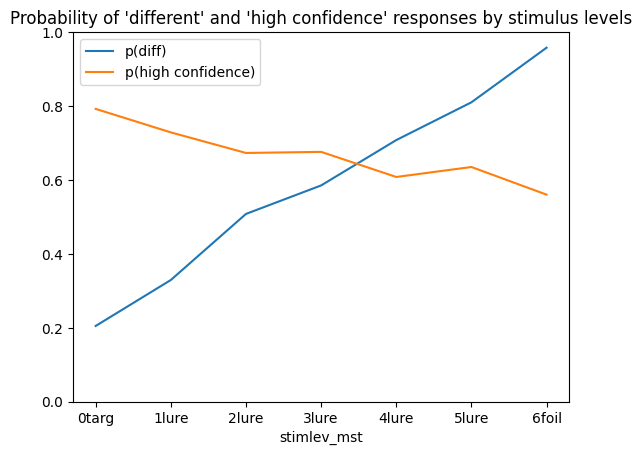

In [28]:
# @title Performance increases by "stimulus level"? Yes
trial_data_merged.groupby('stimlev_mst').mean(numeric_only=True)['resp1_diff'].plot(label='p(diff)')
trial_data_merged.groupby('stimlev_mst').mean(numeric_only=True)['resp2_bin_med'].plot(label='p(high confidence)')
# trial_data_merged.groupby('stimlev_mst').mean(numeric_only=True)['resp2'].plot(label='mean confidence')
plt.ylim(0, 1)
plt.title("Probability of 'different' and 'high confidence' responses by stimulus levels")
plt.legend()
plt.show()

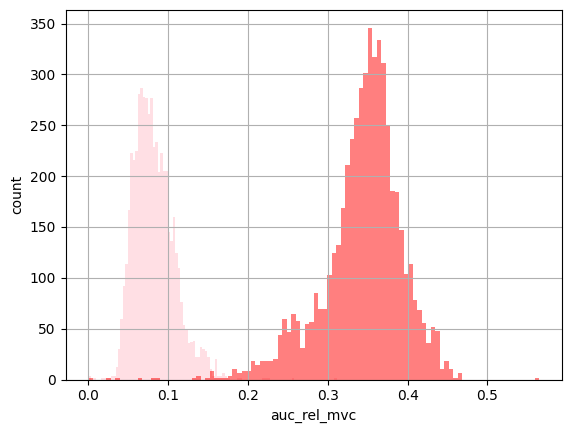

In [29]:
# @title Were participants squeezing for the correct force and duration? Yes
lo_grip = trial_data.query('gf_trPer==0.05')
hi_grip = trial_data.query('gf_trPer==0.4')
lo_grip['auc_rel_mvc'].hist(bins=100, alpha=0.5, color='pink')
hi_grip['auc_rel_mvc'].hist(bins=100, alpha=0.5, color='red')
plt.xlabel("auc_rel_mvc")
plt.ylabel("count")
plt.show()

- as a reminder, auc_rel_mvc is calculated by:
  ```
  auc_rel_mvc = auc / mvc
  ```
  where auc is the area under the curve of the participant's gripforce trajectory for that trial Note that for BAP, this recording is from the start of the handgrip indicator to the start of the response 1 screen ("yes/no")

# Step 6: Save trial-level data


In [30]:
save_csv = input('Save CSV? (y/n): ')
if save_csv=='y':
  trial_data_merged.to_csv(os.path.join(data_dir, 'lcya_behdata_trial_mst.csv'), index=None)

Save CSV? (y/n): y
